## 1. What this notebook computes

The exchange energy is the part of the energy of fermions that comes from the Pauli
principle alone. In general it is an integral over TWO points, but for a contact
interaction (particles feel each other only when they are at the same point) it
becomes an integral over ONE point: it is exactly local. This notebook shows this
step by step for the uniform gas, the system from which the local density
approximation is built. It

- computes the density matrix of one label of the uniform gas in three dimensions
  from its closed form and from sums over the plane waves of a periodic box;
- draws the "exchange hole": the reduced chance of finding a second fermion close
  to a first one, for $g = 1$, $2$ and $8$ labels;
- computes the Hartree and exchange energies of a contact interaction and checks
  the rule $E_x = -E_H/g$ for equally occupied labels;
- lets a Gaussian interaction of range $a$ shrink to a contact and watches the
  exchange energy approach the contact value;
- computes Dirac's exchange energy of the Coulomb interaction for comparison;
- checks that the local exchange formula is exact for ANY Slater determinant, not
  only for the uniform gas;
- shows that exchange favours a gas in which the labels are unequally occupied
  (polarization) when the contact repulsion is strong;
- reproduces, from the Revision gamma matrices, the exchange energy of the uniform
  gas of the 16-component field dirac16complex that the Revision Kohn-Sham solver
  uses;
- draws nine teaching plots.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 13b (Exchange of a contact interaction in a uniform gas) is the file
`Revision/textbook/notebooks/13b_contact_exchange_gas.ipynb` of the repository
Dirac_claude. It computes the one-label density matrix of the uniform Fermi gas (closed
form and box sums), its exchange hole, the Hartree and exchange energies of a contact
interaction with g labels (the rule E_x = -E_H/g), the approach of a finite-range
interaction to the contact limit, Dirac's exchange energy of the Coulomb interaction for
comparison, the exactness of the local exchange formula for any Slater determinant, and
the spin polarization that exchange favours; finally it reproduces, from the Revision
gamma matrices, the exchange energy of the uniform 8-fold gas of dirac16complex recorded
in the Revision Kohn-Sham theory (coefficients -1/32, potentials 15/16 and -1/16,
filled-shell ratio -1/8), and draws nine teaching plots. It needs a computer with Windows
11, macOS or Linux, an internet connection for the installation, the program Git, and
Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these packages at
exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other packages run
Jupyter, the program that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (about 130 MB; the folder then takes about 400
MB of disk space) into the folder Dirac_claude inside your home folder, create a private
Python environment in the folder dirac-book-env inside your home folder (a private
environment is a folder with its own copy of Python and of the packages, so that nothing
else on your computer is changed), activate it (from then on the commands `python` and
`jupyter` typed in this terminal are those of the environment, and the prompt starts with
(dirac-book-env)), and install the packages at the pinned versions (this downloads about
90 MB and takes a few minutes; the environment takes about 400 MB of disk space). If you
have done this step before, for this or for another notebook, skip it and go to Step 4;
to get the newest version of the repository, run `git pull` in the repository folder
after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 13b_contact_exchange_gas.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 10 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 13b_contact_exchange_gas.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
13b_contact_exchange_gas.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/13b.captions.json`
- `Revision/textbook/figures/13b_1_density_matrix.png`
- `Revision/textbook/figures/13b_2_exchange_hole.png`
- `Revision/textbook/figures/13b_3_contact_energies.png`
- `Revision/textbook/figures/13b_4_finite_range.png`
- `Revision/textbook/figures/13b_5_contact_vs_coulomb.png`
- `Revision/textbook/figures/13b_6_local_exchange.png`
- `Revision/textbook/figures/13b_7_polarization.png`
- `Revision/textbook/figures/13b_8_dirac_matrices.png`
- `Revision/textbook/figures/13b_9_dirac_exchange.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the figure file 13b_9_dirac_exchange.png exists
    ALL 34 CHECKS PASSED (notebook 13b)

and the notebook must show 9 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/13b_contact_exchange_gas.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" for `gammas.json` or `ks-theory.json`: the notebook reads Revision
  records of the repository; it must be opened inside the folder
  `Revision/textbook/notebooks` of a complete clone of the repository, not as a single
  downloaded file.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 13b (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 13b (Exchange of a contact interaction in a uniform gas) is the file
# Revision/textbook/notebooks/13b_contact_exchange_gas.ipynb of the repository
# Dirac_claude. It computes the one-label density matrix of the uniform Fermi gas (closed
# form and box sums), its exchange hole, the Hartree and exchange energies of a contact
# interaction with g labels (the rule E_x = -E_H/g), the approach of a finite-range
# interaction to the contact limit, Dirac's exchange energy of the Coulomb interaction
# for comparison, the exactness of the local exchange formula for any Slater determinant,
# and the spin polarization that exchange favours; finally it reproduces, from the
# Revision gamma matrices, the exchange energy of the uniform 8-fold gas of
# dirac16complex recorded in the Revision Kohn-Sham theory (coefficients -1/32,
# potentials 15/16 and -1/16, filled-shell ratio -1/8), and draws nine teaching plots. It
# needs a computer with Windows 11, macOS or Linux, an internet connection for the
# installation, the program Git, and Python 3.12 or newer (the notebooks were built with
# Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy
# 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient
# 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy, sympy
# and matplotlib; the other packages run Jupyter, the program that shows and runs
# notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (about 130 MB; the folder then takes about
# 400 MB of disk space) into the folder Dirac_claude inside your home folder, create a
# private Python environment in the folder dirac-book-env inside your home folder (a
# private environment is a folder with its own copy of Python and of the packages, so
# that nothing else on your computer is changed), activate it (from then on the commands
# python and jupyter typed in this terminal are those of the environment, and the prompt
# starts with (dirac-book-env)), and install the packages at the pinned versions (this
# downloads about 90 MB and takes a few minutes; the environment takes about 400 MB of
# disk space). If you have done this step before, for this or for another notebook, skip
# it and go to Step 4; to get the newest version of the repository, run git pull in the
# repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 13b_contact_exchange_gas.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 10
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 13b_contact_exchange_gas.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 13b_contact_exchange_gas.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/13b.captions.json
# - Revision/textbook/figures/13b_1_density_matrix.png
# - Revision/textbook/figures/13b_2_exchange_hole.png
# - Revision/textbook/figures/13b_3_contact_energies.png
# - Revision/textbook/figures/13b_4_finite_range.png
# - Revision/textbook/figures/13b_5_contact_vs_coulomb.png
# - Revision/textbook/figures/13b_6_local_exchange.png
# - Revision/textbook/figures/13b_7_polarization.png
# - Revision/textbook/figures/13b_8_dirac_matrices.png
# - Revision/textbook/figures/13b_9_dirac_exchange.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the figure file 13b_9_dirac_exchange.png exists
#     ALL 34 CHECKS PASSED (notebook 13b)
#
# and the notebook must show 9 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/13b_contact_exchange_gas.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" for gammas.json or ks-theory.json: the notebook reads Revision
#   records of the repository; it must be opened inside the folder
#   Revision/textbook/notebooks of a complete clone of the repository, not as a single
#   downloaded file.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "13b"  # this notebook: chapter 13, example b


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 13b complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Uniform gas**: infinitely many fermions spread with the same density everywhere;
  it is studied in a large periodic box (a box whose opposite faces are glued
  together), whose volume is then made infinite.
- **Plane wave**: the orbital $e^{i\mathbf k\cdot\mathbf r}/\sqrt V$ of a free
  particle in the box of volume $V$, with wave vector $\mathbf k$; its kinetic energy
  is $k^2/2$ (units $\hbar = m = 1$).
- **Fermi sphere, Fermi wave number** $k_F$: the ground state of the free gas fills
  every plane wave with $|\mathbf k| < k_F$, once per label.
- **Label**: an internal property with $g$ values (for electrons the spin, $g = 2$;
  for the dirac16complex gas of the Revision record, 8 states per momentum).
- **Density matrix** $\rho(x, x')$: $\sum_a \phi_a(x)\,\phi_a^*(x')$ over the occupied
  orbitals; its diagonal $\rho(x, x)$ is the density.
- **Exchange energy** $E_x = -\tfrac12\iint |\rho(x, x')|^2\,w(x, x')\,dx\,dx'$ of a
  Slater determinant with the pair interaction $w$; **Hartree energy**
  $E_H = \tfrac12\iint n(x)\,w(x, x')\,n(x')\,dx\,dx'$.
- **Contact interaction**: $w(\mathbf r, \mathbf r') = g_c\,\delta(\mathbf r -
  \mathbf r')$; it acts only when two particles are at the same point.
- **Exchange hole**: the dip in the probability of finding a second fermion near a
  first one, caused by the Pauli principle.
- **Coulomb interaction**: $w = 1/|\mathbf r - \mathbf r'|$, the repulsion of two
  electrons (atomic units).
- **Polarization** $\zeta = (n_{up} - n_{down})/n$: how unequally two labels are
  occupied.
- **Vertex**: the matrix that sits between the field components in an interaction;
  for dirac16complex the contact interaction is $(\lambda/2)\,S^2$ with
  $S = \bar\Psi\Psi = \Psi^\dagger C\,\Psi$, so the vertex is the $16 \times 16$
  matrix $C$.
- **sympy, Rational**: sympy computes with exact fractions such as $-1/32$, so its
  checks are exact, not rounded.

## 4. The physical and mathematical situation

**The exchange energy of a determinant.** For a Slater determinant with the density
matrix $\rho(x, x') = \sum_{a\,occupied}\phi_a(x)\phi_a^*(x')$, where $x$ stands for
the position $\mathbf r$ and the label $\sigma$ together (this $x$, and the $x$ of
the line in section 10, is not one of the author's spacetime coordinates
$x_1, \dots, x_8$; those appear only in section 12, as the labels of the gamma
matrices $\gamma^{(x1)}, \dots, \gamma^{(x8)}$), the interaction energy is
$E_H + E_x$ with

$$E_H = \tfrac12\iint n(x)\,w(x,x')\,n(x')\,dx\,dx', \qquad
E_x = -\tfrac12\iint |\rho(x,x')|^2\,w(x,x')\,dx\,dx' .$$

**Contact interaction.** With $w = g_c\,\delta(\mathbf r - \mathbf r')$ (the same for
all labels) the delta function sets $\mathbf r' = \mathbf r$ and only one integral
over space remains:

$$E_x = -\frac{g_c}{2}\int \sum_{\sigma,\sigma'}|\rho(\mathbf r\sigma,
\mathbf r\sigma')|^2\,d^3r .$$

If every orbital has a definite label, $\rho(\mathbf r\sigma, \mathbf r\sigma') = 0$
for $\sigma \ne \sigma'$ and $\rho(\mathbf r\sigma,\mathbf r\sigma) = n_\sigma(\mathbf
r)$, so $E_x = -\frac{g_c}{2}\int\sum_\sigma n_\sigma^2\,d^3r$: exactly local. With all
$g$ labels equally occupied, $n_\sigma = n/g$ and $E_x = -E_H/g$.

**The uniform gas.** In a box of volume $V$ the allowed wave vectors form a cubic
lattice of spacing $2\pi/\ell$ ($V = \ell^3$); filling $|\mathbf k| < k_F$ once per
label gives $n_\sigma = k_F^3/(6\pi^2)$. The density matrix of one label depends
only on the separation $R = |\mathbf r - \mathbf r'|$; in spherical coordinates
around $\mathbf R$,

$$\rho_\sigma(R) = \int_{k<k_F}\frac{d^3k}{(2\pi)^3}e^{i\mathbf k\cdot\mathbf R}
= \frac{1}{2\pi^2 R^3}\,[\sin(k_F R) - k_F R\cos(k_F R)] = n_\sigma\,F(k_F R),$$

$$F(s) = \frac{3\,(\sin s - s\cos s)}{s^3}, \qquad F(0) = 1 .$$

**Status.** Everything in sections 5 to 11 is exact mathematics of the free Fermi gas
(PROVED: the formulas above follow from the definitions; this notebook checks them
numerically). Section 11 describes the exchange-only (Hartree-Fock) energy, not the
exact one. The last part reproduces numbers of the Revision record (COMPUTED there
with sympy, recomputed here exactly).

## 5. The density matrix of one label of the uniform gas

The next cell defines the function $F(s)$. For small $s$ the formula
$3(\sin s - s\cos s)/s^3$ divides two tiny numbers and loses digits, so for
$s < 10^{-3}$ the function uses the first terms of its Taylor series,
$F(s) = 1 - s^2/10 + s^4/280$ (expand $\sin$ and $\cos$ and collect the powers).
The check compares the two forms at $s = 10^{-3}$.

In [2]:
import numpy as np  # arrays, matrices and linear algebra


def F(s):
    """F(s) = 3 (sin s - s cos s) / s^3, the density matrix of one label over n."""
    s = np.asarray(s, dtype=float)
    result = 1.0 - s ** 2 / 10.0 + s ** 4 / 280.0  # the Taylor series near 0
    big = s >= 1e-3  # where the closed form is accurate
    sb = s[big]
    result[big] = 3.0 * (np.sin(sb) - sb * np.cos(sb)) / sb ** 3
    return result


s_test = 1e-3
closed = 3.0 * (np.sin(s_test) - s_test * np.cos(s_test)) / s_test ** 3
series = 1.0 - s_test ** 2 / 10.0 + s_test ** 4 / 280.0
say(f"at s = 0.001: closed form {closed:.12f}, series {series:.12f}")
check(abs(closed - series) < 1e-8,
      "the closed form and the series agree at s = 0.001 (to about 9 digits)")

at s = 0.001: closed form 0.999999899944, series 0.999999900000
PASS the closed form and the series agree at s = 0.001 (to about 9 digits)


The closed form came from an integral over the continuum of wave vectors. In a real
(finite) box the wave vectors are the lattice points $\mathbf k = (2\pi/\ell)\,
\mathbf m$ with integer $\mathbf m = (m_x, m_y, m_z)$, and the density matrix is the
SUM $\rho_\sigma(\mathbf R) = \frac1V\sum_{|\mathbf m| < m_F} e^{i\mathbf k\cdot
\mathbf R}$. Along the $x$ axis ($\mathbf R = (R, 0, 0)$) only $m_x$ matters, and the
sine parts cancel between $m_x$ and $-m_x$, so

$$\frac{\rho_\sigma(R)}{n_\sigma} = \frac{1}{N_\sigma}\sum_{m_x} c(m_x)\,
\cos\!\Big(\frac{2\pi m_x R}{\ell}\Big),$$

where $c(m_x)$ counts the lattice points with this $m_x$ inside the sphere and
$N_\sigma = \sum c(m_x)$ is the number of occupied plane waves. The next cell
computes this for spheres of radius $m_F = 4, 8, 16, 32$ lattice steps and compares
it with $F(k_F R)$, where $k_F$ is defined by the count,
$N_\sigma = \frac43\pi\,(k_F \ell/2\pi)^3$. The difference must shrink as the box
holds more particles.

In [3]:
s_grid = np.linspace(0.0, 12.0, 121)  # s = k_F R from 0 to 12
box_results = {}
for m_F in (4, 8, 16, 32):
    m = np.arange(-m_F, m_F + 1)  # the possible integers m_x, m_y, m_z
    my, mz = np.meshgrid(m, m, indexing="ij")  # all pairs (m_y, m_z)
    q = my ** 2 + mz ** 2
    counts = np.array([np.count_nonzero(q < m_F ** 2 - mx ** 2) for mx in m])
    N_label = int(counts.sum())  # occupied plane waves of one label
    kF_ell = 2.0 * np.pi * (3.0 * N_label / (4.0 * np.pi)) ** (1.0 / 3.0)
    R_over_ell = s_grid / kF_ell  # the separations R / ell for these s
    ratio = np.array([np.sum(counts * np.cos(2.0 * np.pi * m * r))
                      for r in R_over_ell]) / N_label
    box_results[m_F] = (N_label, ratio)
    deviation = np.max(np.abs(ratio - F(s_grid)))
    say(f"m_F = {m_F:2d}: {N_label:6d} plane waves; largest difference from "
        f"F = {deviation:.5f}")
deviations = [np.max(np.abs(box_results[m_F][1] - F(s_grid)))
              for m_F in (4, 8, 16, 32)]
shrinking = all(a > b for a, b in zip(deviations, deviations[1:]))
check(shrinking and deviations[-1] < 2e-3,
      "the box sums approach the closed form F as the box holds more particles")

m_F =  4:    251 plane waves; largest difference from F = 0.03729
m_F =  8:   2103 plane waves; largest difference from F = 0.01218
m_F = 16:  17071 plane waves; largest difference from F = 0.00184
m_F = 32: 137059 plane waves; largest difference from F = 0.00083
PASS the box sums approach the closed form F as the box holds more particles


The next cell draws the closed form and the box sums for the smallest and the
largest sphere.

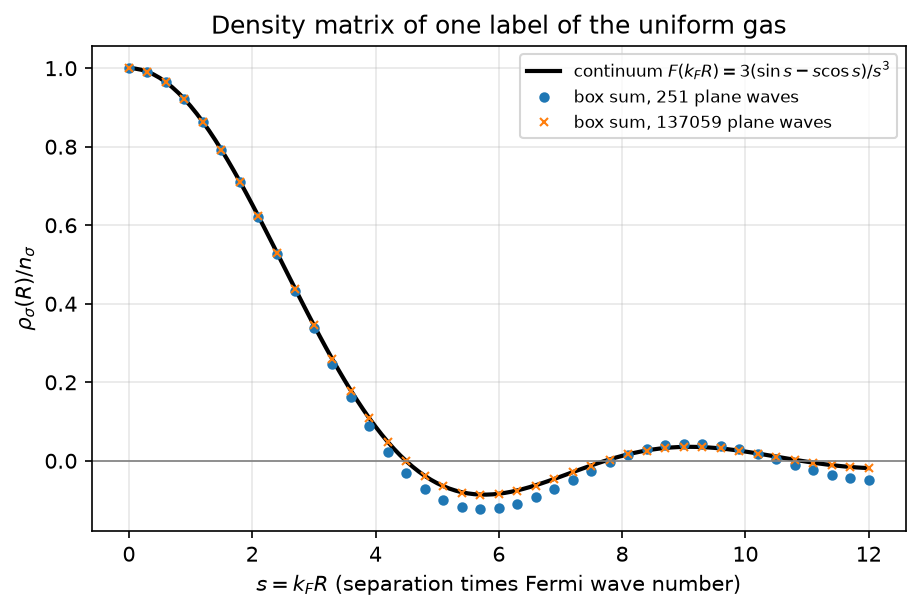

Figure 13b.1 saved as Revision/textbook/figures/13b_1_density_matrix.png


In [4]:
fig, ax = plt.subplots()
ax.plot(s_grid, F(s_grid), color="black", lw=2.0,
        label="continuum $F(k_F R) = 3(\\sin s - s\\cos s)/s^3$")
for m_F, marker in ((4, "o"), (32, "x")):
    N_label, ratio = box_results[m_F]
    ax.plot(s_grid[::3], ratio[::3], marker, ms=4,
            label=f"box sum, {N_label} plane waves")
ax.axhline(0.0, color="gray", lw=0.8)
ax.set_xlabel("$s = k_F R$ (separation times Fermi wave number)")
ax.set_ylabel("$\\rho_\\sigma(R) / n_\\sigma$")
ax.set_title("Density matrix of one label of the uniform gas")
ax.legend(fontsize=8)
save_figure(fig, "density_matrix",
            "The density matrix of one label of the uniform Fermi gas divided by "
            "the density of that label, $\\rho_\\sigma(R)/n_\\sigma = F(k_F R)$, "
            "against $s = k_F R$ (pure number): the closed form (black line) and "
            "the sums over the occupied plane waves of a periodic box with "
            f"{box_results[4][0]} and {box_results[32][0]} plane waves (markers). "
            "It is 1 at $R = 0$, falls to zero near "
            "$k_F R = 4.5$ and then oscillates with a shrinking amplitude; the box "
            "sums approach the curve as the box grows.")

## 6. The exchange hole

For a determinant, the probability density of finding one fermion at $\mathbf r$ and
another at $\mathbf r'$ is $n(\mathbf r)n(\mathbf r') - \sum_\sigma|\rho_\sigma(
\mathbf r,\mathbf r')|^2$ (Wick's theorem). Divided by $n^2$ it is the **pair
distribution** $g_{pair}(R) = 1 - \frac{1}{g}F(k_F R)^2$ for $g$ equally occupied
labels. At $R = 0$ it is $1 - 1/g$: a second fermion with the SAME label is never
found at the same point, one with another label is found as often as without the
Pauli principle. The next cell computes and draws it for $g = 1, 2, 8$.

PASS the pair distribution at contact is 1 - 1/g for g = 1
PASS the pair distribution at contact is 1 - 1/g for g = 2
PASS the pair distribution at contact is 1 - 1/g for g = 8


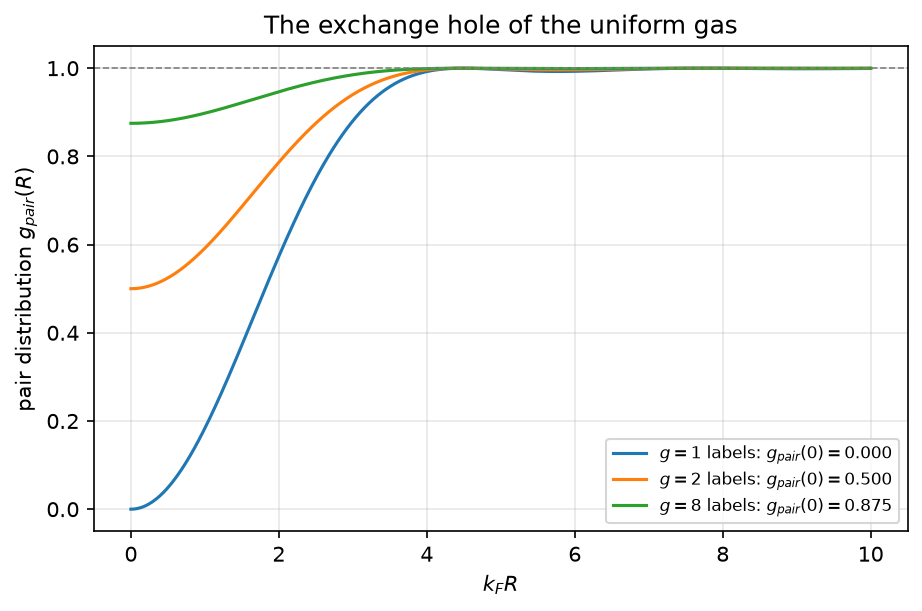

Figure 13b.2 saved as Revision/textbook/figures/13b_2_exchange_hole.png


In [5]:
s_fine = np.linspace(0.0, 10.0, 501)
fig, ax = plt.subplots()
for g in (1, 2, 8):
    pair = 1.0 - F(s_fine) ** 2 / g  # the pair distribution
    ax.plot(s_fine, pair, label=f"$g = {g}$ labels: $g_{{pair}}(0) = {1 - 1 / g:.3f}$")
    check(abs(pair[0] - (1.0 - 1.0 / g)) < 1e-15,
          f"the pair distribution at contact is 1 - 1/g for g = {g}")
ax.axhline(1.0, color="gray", ls="--", lw=0.8)
ax.set_xlabel("$k_F R$")
ax.set_ylabel("pair distribution $g_{pair}(R)$")
ax.set_title("The exchange hole of the uniform gas")
ax.legend(fontsize=8)
save_figure(fig, "exchange_hole",
            "The pair distribution $g_{pair}(R) = 1 - F(k_F R)^2/g$ of the uniform "
            "Fermi gas with $g = 1, 2, 8$ equally occupied labels, against "
            "$k_F R$ (pure numbers): the chance of finding a second fermion at the "
            "distance $R$ from a first one, relative to the chance without the "
            "Pauli principle (dashed line 1). The dip near $R = 0$ is the exchange "
            "hole; its depth at contact is $1/g$, the fraction of fermions that "
            "share the first fermion's label.")

## 7. Hartree and exchange energy of a contact interaction

For the contact interaction the energies per unit volume of the uniform gas are
$e_H = \frac{g_c}{2}n^2$ and $e_x = -\frac{g_c}{2}\sum_\sigma n_\sigma^2 =
-\frac{g_c}{2g}n^2$, so $e_H + e_x = \frac{g_c}{2}n^2\,(1 - 1/g) =
\frac{g_c}{2}n^2\,g_{pair}(0)$: the interaction energy counts only the pairs that can
meet, those with different labels. The next cell computes them for $g = 2$ and
$g = 8$ ($g_c = 1$) and checks the rule $e_x = -e_H/g$; for $g = 1$ the two cancel
exactly: a single label does not feel a contact interaction at all.

In [6]:
G_C = 1.0  # the strength of the contact interaction
densities = np.linspace(0.0, 2.0, 41)  # n from 0 to 2 (particles per volume)


def contact_energies(n, g):
    """(e_H, e_x) per volume for g equally occupied labels: n_sigma = n / g."""
    e_hartree = 0.5 * G_C * n ** 2
    e_exchange = -0.5 * G_C * g * (n / g) ** 2  # -(g_c/2) sum over g labels
    return e_hartree, e_exchange


for g in (1, 2, 8):
    e_hartree, e_exchange = contact_energies(densities, g)
    ratio = e_exchange[1:] / e_hartree[1:]  # skip n = 0 (0/0)
    check(np.allclose(ratio, -1.0 / g, rtol=0, atol=1e-15),
          f"e_x = -e_H/g for g = {g}")
e_hartree, e_exchange = contact_energies(densities, 1)
check(np.max(np.abs(e_hartree + e_exchange)) == 0.0,
      "for a single label the contact interaction cancels exactly")

PASS e_x = -e_H/g for g = 1
PASS e_x = -e_H/g for g = 2
PASS e_x = -e_H/g for g = 8
PASS for a single label the contact interaction cancels exactly


The next cell draws the three energy densities for $g = 2$ (electrons) and
$g = 8$ (the number of good-sector states per momentum of the dirac16complex gas).

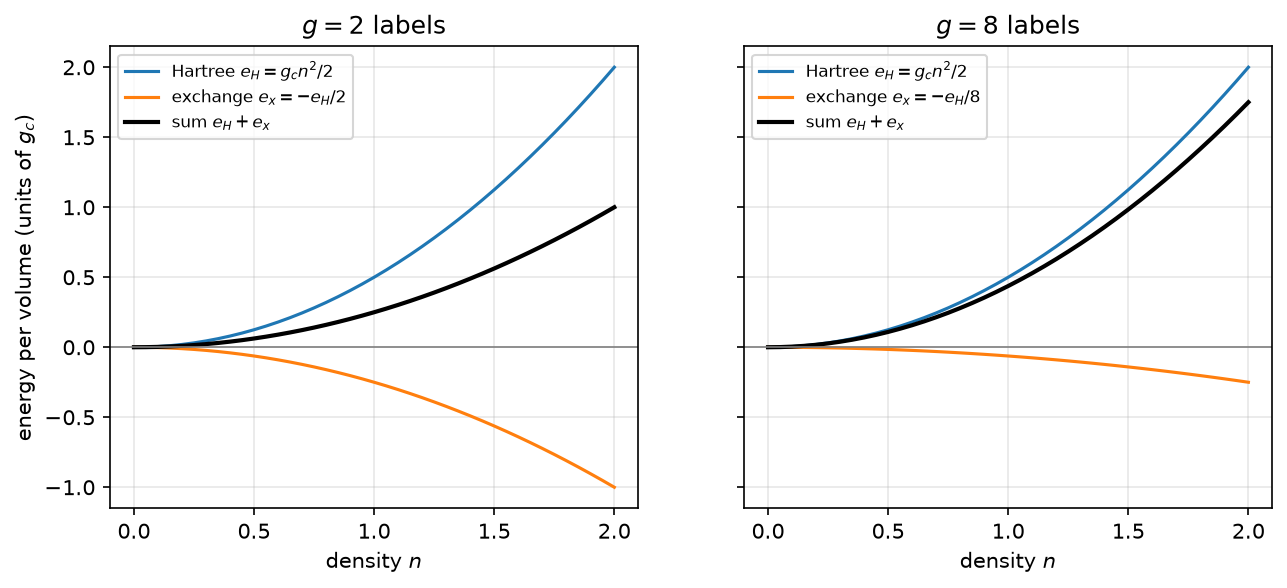

Figure 13b.3 saved as Revision/textbook/figures/13b_3_contact_energies.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.0), sharey=True)
for ax, g in zip(axes, (2, 8)):
    e_hartree, e_exchange = contact_energies(densities, g)
    ax.plot(densities, e_hartree, label="Hartree $e_H = g_c n^2/2$")
    ax.plot(densities, e_exchange, label=f"exchange $e_x = -e_H/{g}$")
    ax.plot(densities, e_hartree + e_exchange, color="black", lw=2.0,
            label="sum $e_H + e_x$")
    ax.axhline(0.0, color="gray", lw=0.8)
    ax.set_xlabel("density $n$")
    ax.set_title(f"$g = {g}$ labels")
    ax.legend(fontsize=8)
axes[0].set_ylabel("energy per volume (units of $g_c$)")
save_figure(fig, "contact_energies",
            "The Hartree energy $e_H = g_c n^2/2$, the exchange energy "
            "$e_x = -e_H/g$ and their sum per unit volume of the uniform gas with "
            "a contact interaction ($g_c = 1$), against the density $n$, for "
            "$g = 2$ labels (left) and $g = 8$ labels (right). Exchange removes "
            "the fraction $1/g$ of the Hartree energy: the pairs of fermions with "
            "the same label, which never meet.")

## 8. A finite-range interaction shrinking to a contact

Replace the contact by a Gaussian of range $a$ and the same total strength,
$w_a(R) = g_c\,(2\pi a^2)^{-3/2}e^{-R^2/(2a^2)}$, whose integral over all space is
$g_c$. Its Hartree energy is still $\frac{g_c}{2}n^2$ (only the integral of $w$
enters for a uniform density), but its exchange energy becomes
$e_x(a) = -\frac12\sum_\sigma n_\sigma^2\int w_a(R)\,F(k_F R)^2\,d^3R$. So
$e_x(a)/e_x(0) = \int_0^\infty 4\pi R^2\,w_a(R)\,F(k_F R)^2\,dR\,/\,g_c$. For small
$a$, $F^2 \approx 1 - s^2/5$ and $\int w_a R^2\,d^3R = 3a^2 g_c$, so
$e_x(a)/e_x(0) \approx 1 - \frac35 (k_F a)^2$. The next cell computes the ratio with
Simpson's rule on a fine grid (in the variable $s = k_F R$, with $a$ measured in
units of $1/k_F$) and checks the small-$a$ formula.

In [8]:
def simpson(values, step):
    """Simpson's rule for equally spaced values (an odd number of them)."""
    return step / 3.0 * (values[0] + values[-1] + 4.0 * values[1:-1:2].sum()
                         + 2.0 * values[2:-1:2].sum())


s_int = np.linspace(0.0, 80.0, 400001)  # s = k_F R; the Gaussian is tiny beyond
ds = s_int[1] - s_int[0]
F2 = F(s_int) ** 2


def exchange_ratio(kF_a):
    """e_x(a) / e_x(0) for the Gaussian of range a (k_F a given)."""
    norm = (2.0 * np.pi * kF_a ** 2) ** -1.5  # makes the integral of w_a equal g_c
    gauss = norm * np.exp(-s_int ** 2 / (2.0 * kF_a ** 2))
    return simpson(4.0 * np.pi * s_int ** 2 * gauss * F2, ds)


ranges = np.logspace(-2, 1, 31)  # k_F a from 0.01 to 10
ratios = np.array([exchange_ratio(r) for r in ranges])
for r in (0.01, 0.1, 1.0):
    say(f"k_F a = {r:5.2f}: e_x(a)/e_x(0) = {exchange_ratio(r):.6f}, "
        f"small-a formula {1.0 - 0.6 * r ** 2:.6f}")
check(abs(exchange_ratio(0.05) - (1.0 - 0.6 * 0.05 ** 2)) < 1e-5,
      "for small range the ratio is 1 - (3/5)(k_F a)^2")
check(np.all(np.diff(ratios) < 0.0) and ratios[0] > 0.9999,
      "the exchange energy grows towards the contact value as the range shrinks")

k_F a =  0.01: e_x(a)/e_x(0) = 0.999940, small-a formula 0.999940
k_F a =  0.10: e_x(a)/e_x(0) = 0.994026, small-a formula 0.994000
k_F a =  1.00: e_x(a)/e_x(0) = 0.588864, small-a formula 0.400000
PASS for small range the ratio is 1 - (3/5)(k_F a)^2
PASS the exchange energy grows towards the contact value as the range shrinks


The next cell draws the ratio against the range on a logarithmic horizontal axis.

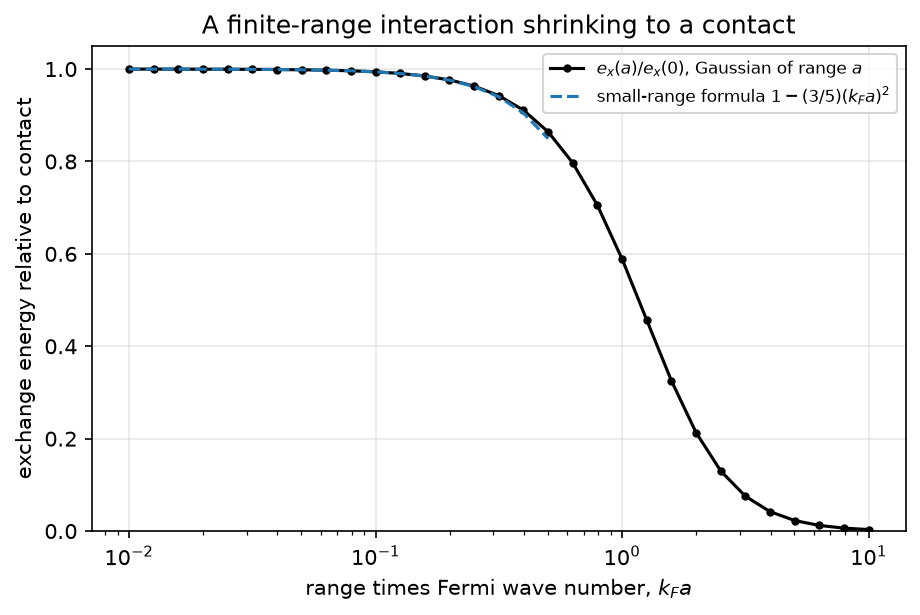

Figure 13b.4 saved as Revision/textbook/figures/13b_4_finite_range.png


In [9]:
fig, ax = plt.subplots()
ax.semilogx(ranges, ratios, "o-", ms=3, color="black",
            label="$e_x(a)/e_x(0)$, Gaussian of range $a$")
small = ranges[ranges < 0.6]
ax.semilogx(small, 1.0 - 0.6 * small ** 2, "--",
            label="small-range formula $1 - (3/5)(k_F a)^2$")
ax.set_ylim(0.0, 1.05)
ax.set_xlabel("range times Fermi wave number, $k_F a$")
ax.set_ylabel("exchange energy relative to contact")
ax.set_title("A finite-range interaction shrinking to a contact")
ax.legend(fontsize=8)
save_figure(fig, "finite_range",
            "The exchange energy of a Gaussian interaction of range $a$ (same total "
            "strength $g_c$) divided by the exchange energy of the contact "
            "interaction, against $k_F a$ on a logarithmic axis (pure numbers), "
            "with the small-range formula $1 - (3/5)(k_F a)^2$ (dashed). When the "
            "range is much smaller than the size $1/k_F$ of the exchange hole the "
            "ratio is 1: the exchange of a contact interaction is local and "
            "exact; for a long range most of the exchange is lost.")

## 9. For comparison: Dirac's exchange energy of the Coulomb interaction

For $w = 1/R$ and $g = 2$ the same formula gives $e_x = -\frac12 \cdot 2\,
n_\sigma^2\int_0^\infty 4\pi R^2\,\frac{F(k_F R)^2}{R}\,dR = -\frac{4\pi
n_\sigma^2}{k_F^2}\int_0^\infty s\,F(s)^2\,ds$, and the integral is $9/4$, which
gives Dirac's result $e_x = -\frac34(3/\pi)^{1/3}n^{4/3}$ (with $n = 2n_\sigma =
k_F^3/(3\pi^2)$). The integrand falls only like $1/s^3$; the next cell integrates
up to $s = 4000$ and adds the tail beyond, $\int_{4000}^\infty 9\cos^2 s/s^3\,ds
\approx 9/(4\cdot 4000^2)$ (the average of $\cos^2$ is $1/2$).

In [10]:
S_MAX = 4000.0
s_long = np.linspace(0.0, S_MAX, 4000001)
integral_9_4 = simpson(s_long * F(s_long) ** 2, s_long[1] - s_long[0])
integral_9_4 += 9.0 / (4.0 * S_MAX ** 2)  # the tail beyond S_MAX
report("integral of s F(s)^2 from 0 to infinity", f"{integral_9_4:.8f}")
check(abs(integral_9_4 - 2.25) < 1e-7, "the Coulomb exchange integral is 9/4")
dirac = 0.75 * (3.0 / np.pi) ** (1.0 / 3.0)  # e_x = -dirac n^(4/3)
n_test = 0.3
kF_test = (3.0 * np.pi ** 2 * n_test) ** (1.0 / 3.0)  # g = 2
e_x_coulomb = -4.0 * np.pi * (n_test / 2) ** 2 / kF_test ** 2 * integral_9_4
report("Dirac's constant (3/4)(3/pi)^(1/3)", f"{dirac:.6f}")
check(abs(e_x_coulomb + dirac * n_test ** (4.0 / 3.0)) < 1e-8,
      "the Coulomb exchange of the electron gas is -(3/4)(3/pi)^(1/3) n^(4/3)")

RESULT integral of s F(s)^2 from 0 to infinity = 2.25000000
PASS the Coulomb exchange integral is 9/4
RESULT Dirac's constant (3/4)(3/pi)^(1/3) = 0.738559
PASS the Coulomb exchange of the electron gas is -(3/4)(3/pi)^(1/3) n^(4/3)


The next cell compares the exchange energy PER PARTICLE of the two interactions on
logarithmic axes: $e_x/n = -g_c n/4$ for the contact ($g = 2$) and
$-\frac34(3/\pi)^{1/3}n^{1/3}$ for the Coulomb interaction. On such axes a power
$n^p$ is a straight line of slope $p$; the check fits the slopes.

slopes: contact 1.000000, Coulomb 0.333333
PASS exchange per particle grows like n (contact) and n^(1/3) (Coulomb)


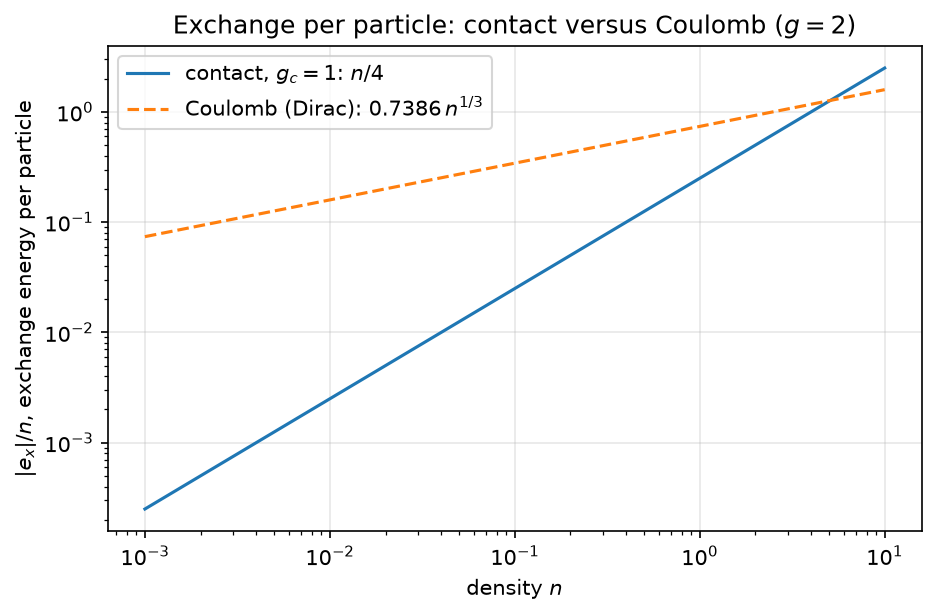

Figure 13b.5 saved as Revision/textbook/figures/13b_5_contact_vs_coulomb.png


In [11]:
n_values = np.logspace(-3, 1, 41)
contact_per_particle = 0.25 * G_C * n_values  # |e_x / n| for the contact, g = 2
coulomb_per_particle = dirac * n_values ** (1.0 / 3.0)  # |e_x / n|, Coulomb
slope_contact = np.polyfit(np.log(n_values), np.log(contact_per_particle), 1)[0]
slope_coulomb = np.polyfit(np.log(n_values), np.log(coulomb_per_particle), 1)[0]
say(f"slopes: contact {slope_contact:.6f}, Coulomb {slope_coulomb:.6f}")
check(abs(slope_contact - 1.0) < 1e-12 and abs(slope_coulomb - 1.0 / 3.0) < 1e-12,
      "exchange per particle grows like n (contact) and n^(1/3) (Coulomb)")
fig, ax = plt.subplots()
ax.loglog(n_values, contact_per_particle, label="contact, $g_c = 1$: $n/4$")
ax.loglog(n_values, coulomb_per_particle, "--",
          label="Coulomb (Dirac): $0.7386\\,n^{1/3}$")
ax.set_xlabel("density $n$")
ax.set_ylabel("$|e_x|/n$, exchange energy per particle")
ax.set_title("Exchange per particle: contact versus Coulomb ($g = 2$)")
ax.legend()
save_figure(fig, "contact_vs_coulomb",
            "The size of the exchange energy per particle of a uniform gas with "
            "two labels, against the density, on logarithmic axes: contact "
            "interaction $g_c n/4$ with $g_c = 1$ (solid) and Coulomb interaction "
            "$(3/4)(3/\\pi)^{1/3}n^{1/3}$ in atomic units (dashed). The slopes 1 and "
            "1/3 show the powers; the contact exchange is a function of the local "
            "density alone because the interaction has no range, the Coulomb one "
            "because the gas is uniform.")

## 10. The local formula is exact for ANY determinant

The uniform gas is special. Is the local contact exchange also exact for a
non-uniform determinant? The next cell takes a line $0 < x < 1$ cut into 99 grid
points (spacing $h = 1/100$) and the orbitals of a particle in this box: five with
label up and three with label down. On the grid the contact is the matrix
$W(x, x') = g_c\,\delta_{xx'}/h$ (one integral times $h$ gives back $g_c$). The
cell computes the exchange energy in the two-point (Fock) form
$-\frac12\sum_{x,x'} h^2\,|\rho_\sigma(x,x')|^2\,W(x,x')$ summed over the labels,
and in the local form $-\frac{g_c}{2}\sum_x h\,(n_{up}^2 + n_{down}^2)$.

In [12]:
P = 99  # interior grid points of the box 0 < x < 1
h = 1.0 / (P + 1)
x = h * np.arange(1, P + 1)
W = G_C * np.eye(P) / h  # the contact interaction on the grid


def box_orbitals(count):
    """The lowest box orbitals sqrt(2) sin(m pi x), m = 1..count, as columns."""
    return np.array([np.sqrt(2.0) * np.sin(m * np.pi * x)
                     for m in range(1, count + 1)]).T


phi_up, phi_down = box_orbitals(5), box_orbitals(3)
rho_up = phi_up @ phi_up.T  # rho_up(x, x') = sum_a phi_a(x) phi_a(x')
rho_down = phi_down @ phi_down.T
n_up, n_down = np.diag(rho_up), np.diag(rho_down)  # the label densities
fock = -0.5 * h * h * (np.sum(rho_up ** 2 * W) + np.sum(rho_down ** 2 * W))
local = -0.5 * G_C * h * np.sum(n_up ** 2 + n_down ** 2)
report("exchange energy, two-point (Fock) form", f"{fock:.10f}")
report("exchange energy, local form", f"{local:.10f}")
check(abs(h * n_up.sum() - 5.0) < 1e-12 and abs(h * n_down.sum() - 3.0) < 1e-12,
      "the box determinant holds 5 up and 3 down fermions")
check(abs(fock - local) < 1e-12,
      "the contact exchange of a non-uniform determinant is exactly local")

RESULT exchange energy, two-point (Fock) form = -19.0000000000
RESULT exchange energy, local form = -19.0000000000
PASS the box determinant holds 5 up and 3 down fermions
PASS the contact exchange of a non-uniform determinant is exactly local


Orbitals need not have a definite label: an orbital may have an up part AND a down
part (a column of $2 \times 99$ numbers). The next cell builds five such orbitals at
random (orthonormal, from the QR factorisation of a random complex matrix with a
fixed seed, so every run gives the same numbers) and compares three numbers: the
exact exchange from the orbital-pair sum
$-\frac12\sum_{a,b}w_{abba}$, with
$w_{abba} = g_c\sum_x h\,|\sum_\sigma \phi_a^*(x\sigma)\phi_b(x\sigma)|^2$; the local
formula with ALL label pairs, $-\frac{g_c}{2}\sum_x h\sum_{\sigma\sigma'}
|\rho(x\sigma, x\sigma')|^2$; and the local formula with only the label diagonal,
$-\frac{g_c}{2}\sum_x h\sum_\sigma n_\sigma^2$. The first two must agree; the third
misses the label-mixing part.

In [13]:
rng = np.random.default_rng(12345)  # a fixed seed: the same numbers every run
raw = rng.normal(size=(2 * P, 5)) + 1j * rng.normal(size=(2 * P, 5))
q_matrix = np.linalg.qr(raw)[0]  # five orthonormal columns of length 2P
spinor = (q_matrix / np.sqrt(h)).reshape(P, 2, 5)  # [point, label, orbital]
# pair[x, a, b] = sum over the label of phi_a*(x, label) phi_b(x, label)
pair = np.einsum("xsa,xsb->xab", spinor.conj(), spinor)
exact = -0.5 * G_C * h * np.sum(np.abs(pair) ** 2)
# rho[x, s, t] = sum_a phi_a(x, s) phi_a*(x, t): the local 2 x 2 density matrix
rho_local = np.einsum("xsa,xta->xst", spinor, spinor.conj())
local_all = -0.5 * G_C * h * np.sum(np.abs(rho_local) ** 2)
diagonal = np.einsum("xss->xs", rho_local).real  # n_up(x), n_down(x)
local_diagonal = -0.5 * G_C * h * np.sum(diagonal ** 2)
say(f"exact {exact:.10f}; local, all label pairs {local_all:.10f}; "
    f"local, label diagonal only {local_diagonal:.10f}")
check(abs(exact - local_all) < 1e-10,
      "with label-mixing orbitals the exchange is local in the 2 x 2 matrix rho")
check(abs(exact - local_diagonal) > 0.1,
      "the label diagonal alone misses the label-mixing exchange")

exact -8.7398756465; local, all label pairs -8.7398756465; local, label diagonal only
    -7.5021209026
PASS with label-mixing orbitals the exchange is local in the 2 x 2 matrix rho
PASS the label diagonal alone misses the label-mixing exchange


The next cell draws the two-point function $|\rho_{up}(x, x')|^2$ of the box
determinant as a heat map (left) and, along the line, the local Hartree and exchange
energy densities (right). For a contact interaction only the diagonal $x = x'$ of the
heat map enters the exchange energy.

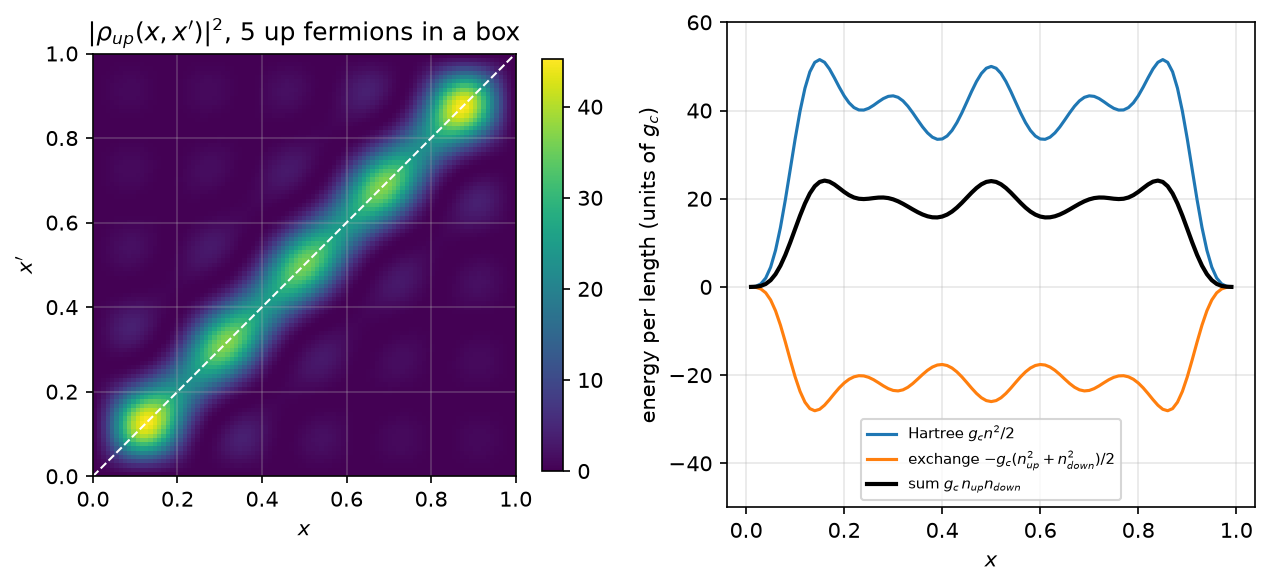

Figure 13b.6 saved as Revision/textbook/figures/13b_6_local_exchange.png
PASS Hartree plus exchange of a contact is g_c n_up n_down at every point


In [14]:
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.2))
image = left.imshow(rho_up ** 2, origin="lower", extent=(0, 1, 0, 1),
                    cmap="viridis")
left.plot([0, 1], [0, 1], "w--", lw=1.0)  # the diagonal x = x'
left.set_xlabel("$x$")
left.set_ylabel("$x'$")
left.set_title("$|\\rho_{up}(x, x')|^2$, 5 up fermions in a box")
fig.colorbar(image, ax=left, shrink=0.85)
right.plot(x, 0.5 * G_C * (n_up + n_down) ** 2, label="Hartree $g_c n^2/2$")
right.plot(x, -0.5 * G_C * (n_up ** 2 + n_down ** 2),
           label="exchange $-g_c(n_{up}^2 + n_{down}^2)/2$")
right.plot(x, G_C * n_up * n_down, color="black", lw=2.0,
           label="sum $g_c\\,n_{up} n_{down}$")
right.set_ylim(-50.0, 60.0)  # room below the curves for the legend
right.set_xlabel("$x$")
right.set_ylabel("energy per length (units of $g_c$)")
right.legend(fontsize=7, loc="lower center")
save_figure(fig, "local_exchange",
            "Left: the two-point function $|\\rho_{up}(x, x')|^2$ of five fermions "
            "with label up in the box $0 < x < 1$ as a heat map (both axes the "
            "position; bright means large); a contact interaction uses only its "
            "diagonal $x = x'$ (dashed). Right: the local Hartree energy density, "
            "the local exchange energy density and their sum "
            "$g_c\\,n_{up}n_{down}$ along the box (5 up and 3 down fermions, "
            "$g_c = 1$): exchange removes the same-label part of the Hartree "
            "energy point by point.")
check(np.allclose(0.5 * (n_up + n_down) ** 2 - 0.5 * (n_up ** 2 + n_down ** 2),
                  n_up * n_down, atol=1e-12),
      "Hartree plus exchange of a contact is g_c n_up n_down at every point")

## 11. Exchange favours polarization

Exchange lowers the energy of equal-label pairs only. A gas with two labels can
therefore lower its interaction energy by occupying the labels unequally, at the
price of more kinetic energy (the more occupied label needs a bigger Fermi sphere).
With the polarization $\zeta$, $n_{up} = n(1+\zeta)/2$, $n_{down} = n(1-\zeta)/2$,
the energy per volume in this exchange-only (Hartree-Fock) picture is

$$e(\zeta) = C_F n^{5/3}\,\frac{(1+\zeta)^{5/3} + (1-\zeta)^{5/3}}{2}
+ \frac{g_c}{4}n^2(1 - \zeta^2), \qquad C_F = \tfrac{3}{10}(3\pi^2)^{2/3}.$$

The second derivative at $\zeta = 0$ is $\frac{10}{9}C_F n^{5/3} - \frac{g_c}{2}n^2$,
which turns negative (the unpolarized gas becomes unstable) when
$g_c n^{1/3} > \gamma_c = \frac{20}{9}C_F = \frac23(3\pi^2)^{2/3}$. The next cell
checks this threshold with a difference quotient and draws $e(\zeta) - e(0)$ for
several couplings $\gamma = g_c n^{1/3}/\gamma_c$ (at $n = 1$). This is a property of
the exchange-only functional; correlation, which is left out here, weakens it.

RESULT C_F = 2.871234
RESULT threshold gamma_c = g_c n^(1/3) = 6.380520
PASS the unpolarized gas becomes unstable at g_c n^(1/3) = (2/3)(3 pi^2)^(2/3)


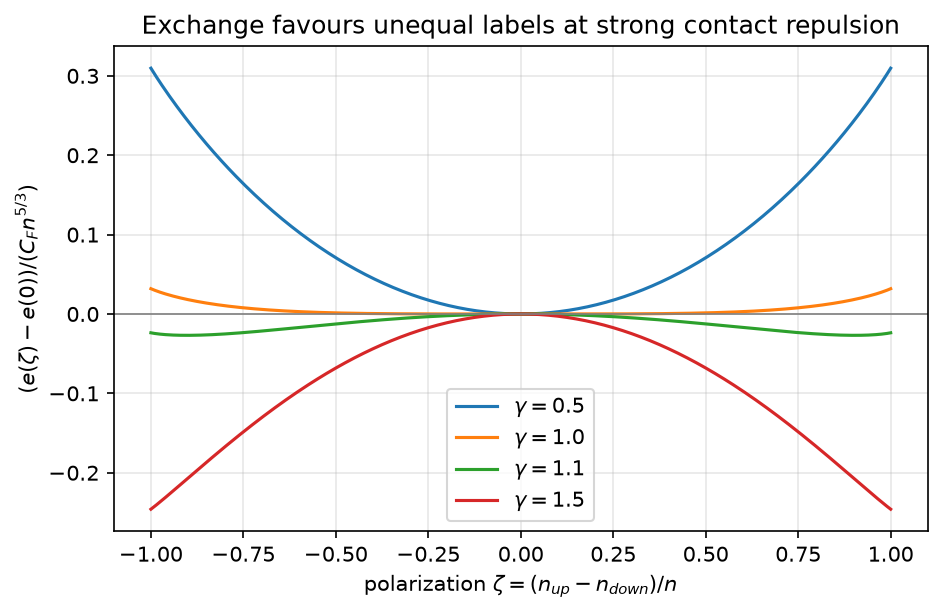

Figure 13b.7 saved as Revision/textbook/figures/13b_7_polarization.png


In [15]:
C_F = 0.3 * (3.0 * np.pi ** 2) ** (2.0 / 3.0)
gamma_c = (2.0 / 3.0) * (3.0 * np.pi ** 2) ** (2.0 / 3.0)


def energy_polarized(zeta, coupling):
    """e(zeta) at n = 1 for g_c = coupling (exchange-only picture)."""
    kinetic_part = C_F * ((1 + zeta) ** (5 / 3) + (1 - zeta) ** (5 / 3)) / 2
    return kinetic_part + 0.25 * coupling * (1 - zeta ** 2)


report("C_F", f"{C_F:.6f}")
report("threshold gamma_c = g_c n^(1/3)", f"{gamma_c:.6f}")
d = 1e-3
curvature = [(energy_polarized(d, c) - 2 * energy_polarized(0.0, c)
              + energy_polarized(-d, c)) / d ** 2
             for c in (0.99 * gamma_c, 1.01 * gamma_c)]
check(curvature[0] > 0 > curvature[1],
      "the unpolarized gas becomes unstable at g_c n^(1/3) = (2/3)(3 pi^2)^(2/3)")
zetas = np.linspace(-1.0, 1.0, 401)
fig, ax = plt.subplots()
for gamma in (0.5, 1.0, 1.1, 1.5):
    curve = energy_polarized(zetas, gamma * gamma_c) - energy_polarized(0.0,
                                                                     gamma * gamma_c)
    ax.plot(zetas, curve / C_F, label=f"$\\gamma = {gamma}$")
ax.axhline(0.0, color="gray", lw=0.8)
ax.set_xlabel("polarization $\\zeta = (n_{up} - n_{down})/n$")
ax.set_ylabel("$(e(\\zeta) - e(0)) / (C_F n^{5/3})$")
ax.set_title("Exchange favours unequal labels at strong contact repulsion")
ax.legend()
save_figure(fig, "polarization",
            "The energy per volume of a uniform gas with two labels and a contact "
            "repulsion in the exchange-only (Hartree-Fock) picture, relative to "
            "the unpolarized gas and in units of $C_F n^{5/3}$, against the "
            "polarization $\\zeta$, for four couplings "
            "$\\gamma = g_c n^{1/3}/\\gamma_c$. Below $\\gamma = 1$ the unpolarized "
            "gas ($\\zeta = 0$) has the lowest energy; above it the curve bends "
            "down at $\\zeta = 0$ and polarized states are lower.")

## 12. The same exchange for the 16-component field dirac16complex

The Kohn-Sham model of the dirac16complex field in the Revision record has the
contact interaction $U = (\lambda/2)\,S^2$ with the scalar density
$S = \bar\Psi\Psi = \Psi^\dagger C\,\Psi$. Its expectation values follow the rule
$\langle\Psi^\dagger M\Psi\rangle = \mathrm{Tr}(M\rho)$ with a local
$16 \times 16$ one-body matrix $\rho$, and Wick's theorem gives, exactly as for the
labels above,

$$e_H = \frac{\lambda}{2}\,(\mathrm{Tr}\,C\rho)^2, \qquad
e_x = -\frac{\lambda}{2}\,\mathrm{Tr}(C\rho\,C\rho).$$

(For $g$ ordinary labels the vertex is the unit matrix and $\rho = (n/g)\,1$, which
gives back $e_x = -\frac{g_c}{2}\,n^2/g$.) For the uniform good-sector gas the
Revision record finds $\rho = (n B + S C)/16$, with the number density
$n = \mathrm{Tr}(B\rho)$ and $B = -i\,C\gamma^{(x4)}$. The next cell reads the
author's gamma matrices EXACTLY (as fractions) from the Revision record, builds $C$
and $B$, and checks them against the matrices stored in the same record.

In [16]:
import sympy as sp  # exact algebra with fractions and symbols

gamma_record = json.loads(repository_file("Revision/algebra/gammas.json")
                          .read_text(encoding="utf-8"))


def exact_matrix(rows):
    """A sympy matrix of exact fractions from the record's rows of numbers."""
    return sp.Matrix([[sp.Rational(str(entry)) for entry in row] for row in rows])


gamma = [exact_matrix(rows) for rows in gamma_record["gamma"]]  # x1 .. x8
C = gamma[7] * gamma[0] * gamma[1] * gamma[2]  # C = g(x8) g(x1) g(x2) g(x3)
B = -sp.I * C * gamma[3]  # B = -i C g(x4)
B_record = (exact_matrix(gamma_record["B"]["re"])
            + sp.I * exact_matrix(gamma_record["B"]["im"]))
check(C == exact_matrix(gamma_record["C"]) and B == B_record,
      "C and B built from the gammas equal the matrices of the record")
check(C * C == sp.eye(16) and B * B == sp.eye(16) and C == C.T,
      "C is symmetric with C^2 = 1, and B^2 = 1")

PASS C and B built from the gammas equal the matrices of the record
PASS C is symmetric with C^2 = 1, and B^2 = 1


The next cell builds $\rho = (nB + SC)/16$ with symbols $n$, $S$, $\lambda$, checks
that it gives back the densities ($\mathrm{Tr}\,B\rho = n$, $\mathrm{Tr}\,C\rho = S$),
computes $e_H$ and $e_x$ exactly, and compares them with the Revision record: the
exchange coefficients $-1/32$ of $n^2$ and of $S^2$ (Revision/kohn_sham/
ks-theory.json and the solver's parameter file) and the checks of the independent
sympy verification (Revision/kohn_sham/reports/ks-theory-python.json).

In [17]:
n_sym, S_sym, lam = sp.symbols("n S lambda", real=True)
rho = (n_sym * B + S_sym * C) / 16
check(sp.simplify((B * rho).trace() - n_sym) == 0
      and sp.simplify((C * rho).trace() - S_sym) == 0,
      "Tr(B rho) = n and Tr(C rho) = S")
e_H = sp.expand(lam / 2 * (C * rho).trace() ** 2)
e_x = sp.expand(-lam / 2 * (C * rho * C * rho).trace())
say(f"e_H = {e_H}")
say(f"e_x = {e_x}")
theory = json.loads(repository_file("Revision/kohn_sham/ks-theory.json")
                    .read_text(encoding="utf-8"))
gas = theory["exchange"]["uniformGas"]
coefficient_n2 = sp.Rational(gas["coefficient_n2"])  # "-1/32" in the record
coefficient_S2 = sp.Rational(gas["coefficient_S2"])
check(e_H == lam * S_sym ** 2 / 2, "the Hartree energy is (lambda/2) S^2")
recorded = lam * (coefficient_n2 * n_sym ** 2 + coefficient_S2 * S_sym ** 2)
check(sp.expand(e_x - recorded) == 0
      and coefficient_n2 == coefficient_S2 == sp.Rational(-1, 32),
      "e_x = -(lambda/32)(n^2 + S^2)",
      record="Revision/kohn_sham/reports/ks-theory-python.json, check "
             "exchange_uniform_gas")

PASS Tr(B rho) = n and Tr(C rho) = S
e_H = S**2*lambda/2
e_x = -S**2*lambda/32 - lambda*n**2/32
PASS the Hartree energy is (lambda/2) S^2
PASS e_x = -(lambda/32)(n^2 + S^2)
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    exchange_uniform_gas


The Kohn-Sham potentials are the derivatives of $e_{int} = e_H + e_x$: the
effective mass $M_{eff} = m + \partial e_{int}/\partial S$ and the vector potential
$v_v = \partial e_{int}/\partial n$. One filled 8-fold level at rest has $n = S$; the
ratio $E_x/E_H$ is then $-1/8$, the analogue of $-1/g$ with $g = 8$. The next cell
computes all three exactly and compares them with the record and with the numbers
that the Revision solver uses.

In [18]:
e_int = e_H + e_x
mass_coefficient = sp.simplify(sp.diff(e_int, S_sym) / (lam * S_sym))  # 15/16
vector_coefficient = sp.simplify(sp.diff(e_int, n_sym) / (lam * n_sym))  # -1/16
filled_ratio = sp.simplify((e_x / e_H).subs(n_sym, S_sym))  # n = S
say(f"M_eff = m + ({mass_coefficient}) lambda S;  v_v = ({vector_coefficient}) "
    f"lambda n;  E_x/E_H at n = S: {filled_ratio}")
potentials = theory["exchange"]["kohnShamPotentials"]
check(mass_coefficient == sp.Rational(potentials["Meff_coefficient_of_lambda_S"])
      == sp.Rational(15, 16)
      and vector_coefficient == sp.Rational(potentials["vv_coefficient_of_lambda_n"])
      == sp.Rational(-1, 16),
      "M_eff = m + (15/16) lambda S and v_v = -(1/16) lambda n",
      record="Revision/kohn_sham/reports/ks-theory-python.json, check ks_potentials")
check(filled_ratio == sp.Rational(-1, 8),
      "one filled 8-fold level at rest: E_x/E_H = -1/8",
      record="Revision/kohn_sham/reports/ks-theory-python.json, check "
             "filled_shell_ratio")
solver = json.loads(repository_file("Revision/kohn_sham/results/parameters.json")
                    .read_text(encoding="utf-8"))["theoryInputs"]
check(solver["exchangeCoefficientN2"] == solver["exchangeCoefficientS2"] == -1 / 32
      and solver["MeffCoefficientOfLambdaS"] == 15 / 16
      and solver["vvCoefficientOfLambdaN"] == -1 / 16,
      "the Revision solver uses exactly these coefficients (parameters.json)")
report_checks = {c["name"]: c["verdict"] for c in json.loads(repository_file(
    "Revision/kohn_sham/reports/ks-theory-python.json").read_text(
    encoding="utf-8"))["checks"]}
check(all(report_checks[name] == "PASS" for name in
          ("exchange_uniform_gas", "ks_potentials", "filled_shell_ratio")),
      "the three Revision checks are recorded as PASS")

M_eff = m + (15/16) lambda S;  v_v = (-1/16) lambda n;  E_x/E_H at n = S: -1/8
PASS M_eff = m + (15/16) lambda S and v_v = -(1/16) lambda n
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check ks_potentials
PASS one filled 8-fold level at rest: E_x/E_H = -1/8
     reproduces Revision/kohn_sham/reports/ks-theory-python.json, check
    filled_shell_ratio
PASS the Revision solver uses exactly these coefficients (parameters.json)
PASS the three Revision checks are recorded as PASS


The next cell draws the two matrices of the vertex and the density rule as heat
maps: $C$ is real (entries $0, \pm 1$) and $B$ is purely imaginary, so its imaginary
part is drawn.

PASS B is purely imaginary
PASS every row of C and of B has exactly one nonzero entry


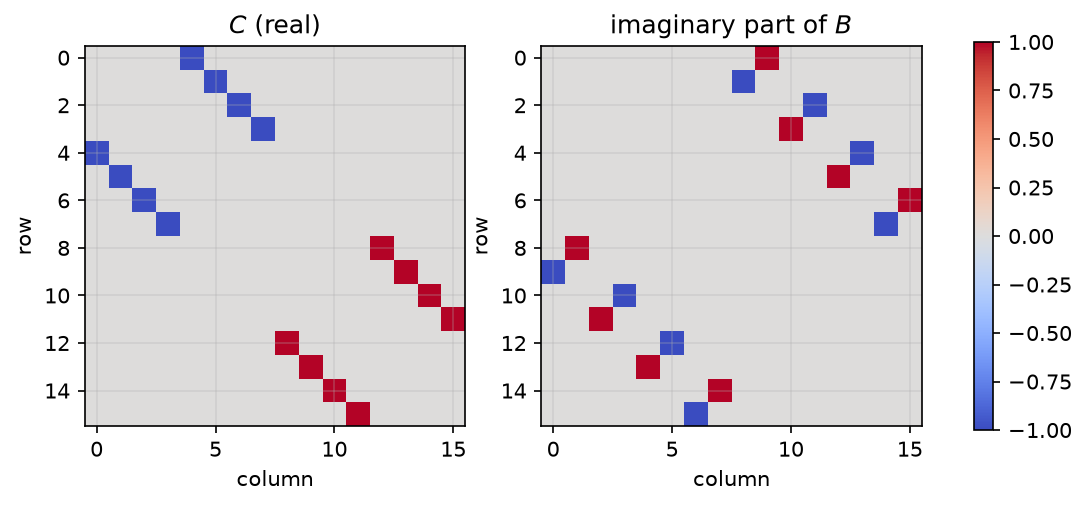

Figure 13b.8 saved as Revision/textbook/figures/13b_8_dirac_matrices.png


In [19]:
C_numbers = np.array(C.tolist(), dtype=float)
B_imaginary = np.array([[float(sp.im(entry)) for entry in row] for row in B.tolist()])
check(all(sp.re(entry) == 0 for entry in B), "B is purely imaginary")
check(all(np.count_nonzero(row) == 1 for row in np.vstack([C_numbers, B_imaginary])),
      "every row of C and of B has exactly one nonzero entry")
fig, axes = plt.subplots(1, 2, figsize=(9.0, 4.2))
for ax, matrix, title in ((axes[0], C_numbers, "$C$ (real)"),
                          (axes[1], B_imaginary, "imaginary part of $B$")):
    image = ax.imshow(matrix, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("column")
    ax.set_ylabel("row")
fig.colorbar(image, ax=axes, shrink=0.8)
save_figure(fig, "dirac_matrices",
            "Heat maps of the $16 \\times 16$ matrices of the contact interaction "
            "of dirac16complex, built exactly from the author's gamma matrices of "
            "the Revision record: the vertex $C = \\gamma^{(x8)}\\gamma^{(x1)}"
            "\\gamma^{(x2)}\\gamma^{(x3)}$ (left; red $+1$, blue $-1$, grey 0) "
            "and the imaginary part of $B = -i\\,C\\gamma^{(x4)}$ (right); rows and "
            "columns are the 16 spinor components. Each row of either matrix has "
            "exactly one nonzero entry.")

Finally, the next cell draws $e_H$, $e_x$ and $e_{int}$ per unit $\lambda n^2$
against the ratio $S/n$ (for a gas at rest $S = n$; moving particles have
$S < n$), and marks the filled level at rest, where $e_x/e_H = -1/8$.

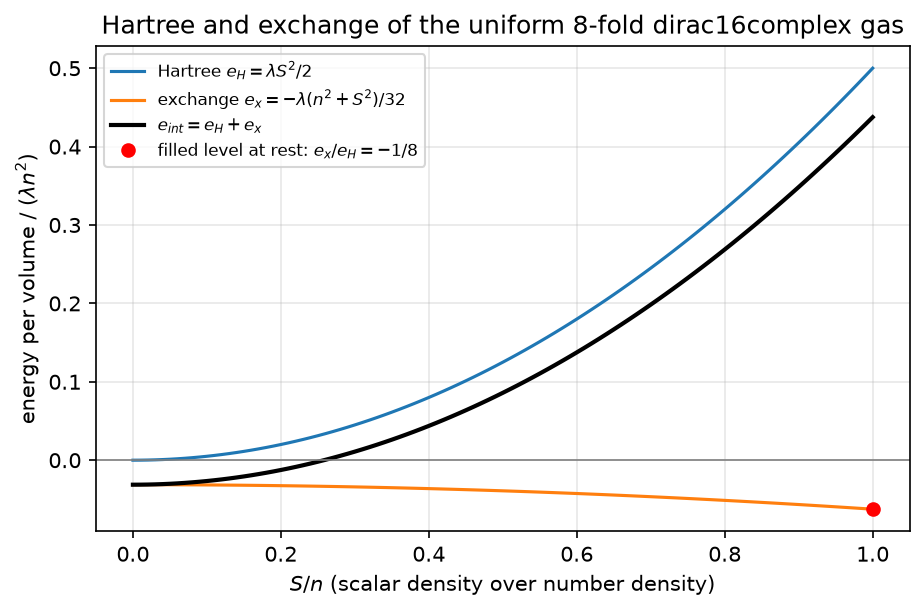

Figure 13b.9 saved as Revision/textbook/figures/13b_9_dirac_exchange.png
PASS the plotted curves give e_x/e_H = -1/8 at S = n


In [20]:
ratio_values = np.linspace(0.0, 1.0, 101)  # S / n
e_H_curve = 0.5 * ratio_values ** 2  # e_H / (lambda n^2)
e_x_curve = -(1.0 + ratio_values ** 2) / 32.0  # e_x / (lambda n^2)
fig, ax = plt.subplots()
ax.plot(ratio_values, e_H_curve, label="Hartree $e_H = \\lambda S^2/2$")
ax.plot(ratio_values, e_x_curve, label="exchange $e_x = -\\lambda(n^2+S^2)/32$")
ax.plot(ratio_values, e_H_curve + e_x_curve, color="black", lw=2.0,
        label="$e_{int} = e_H + e_x$")
ax.plot([1.0], [-1.0 / 16.0], "o", color="red",
        label="filled level at rest: $e_x/e_H = -1/8$")
ax.axhline(0.0, color="gray", lw=0.8)
ax.set_xlabel("$S/n$ (scalar density over number density)")
ax.set_ylabel("energy per volume / $(\\lambda n^2)$")
ax.set_title("Hartree and exchange of the uniform 8-fold dirac16complex gas")
ax.legend(fontsize=8)
save_figure(fig, "dirac_exchange",
            "The Hartree energy $e_H = \\lambda S^2/2$, the exchange energy "
            "$e_x = -\\lambda(n^2 + S^2)/32$ and their sum per unit volume of the "
            "uniform good-sector gas of dirac16complex, in units of "
            "$\\lambda n^2$, against $S/n$ (pure number), as recorded in the "
            "Revision Kohn-Sham theory and reproduced here from the gamma "
            "matrices. The red point is one filled level at rest ($S = n$), where "
            "$e_x = -e_H/8$, the rule $-1/g$ with $g = 8$.")
check(abs(e_x_curve[-1] / e_H_curve[-1] + 1.0 / 8.0) < 1e-15,
      "the plotted curves give e_x/e_H = -1/8 at S = n")

## 13. The last check

The last cell checks that all nine figure files exist and prints the number of
checks that passed.

In [21]:
figure_names = ["density_matrix", "exchange_hole", "contact_energies",
                "finite_range", "contact_vs_coulomb", "local_exchange",
                "polarization", "dirac_matrices", "dirac_exchange"]
missing = [name for k, name in enumerate(figure_names, 1)
           if not output_file(f"{FIGURE_FOLDER}/13b_{k}_{name}.png").is_file()]
check(missing == [], "all nine figure files exist")
check(output_file(f"{FIGURE_FOLDER}/13b_9_dirac_exchange.png").is_file(),
      "the figure file 13b_9_dirac_exchange.png exists")
all_checks_passed()

PASS all nine figure files exist
PASS the figure file 13b_9_dirac_exchange.png exists
ALL 34 CHECKS PASSED (notebook 13b)


## 14. What this notebook showed

- The density matrix of one label of the uniform gas is $n_\sigma F(k_F R)$ with
  $F(s) = 3(\sin s - s\cos s)/s^3$; finite boxes approach it as they grow.
- The Pauli principle digs an exchange hole of depth $1/g$ at contact; a contact
  interaction therefore feels only pairs of different labels:
  $E_H + E_x = \frac{g_c}{2}\int n^2(1 - 1/g)$, i.e. $E_x = -E_H/g$, and for a single
  label the interaction cancels completely.
- The exchange energy of a contact interaction is EXACTLY local, for the uniform gas
  and for every Slater determinant (with label-mixing orbitals it is local in the
  local $2\times 2$ density matrix); a finite range spoils this when the range
  becomes comparable with the size $1/k_F$ of the exchange hole. The Coulomb
  interaction gives Dirac's $-\frac34(3/\pi)^{1/3}n^{4/3}$ instead.
- In the exchange-only picture a strong contact repulsion makes the unpolarized gas
  unstable at $g_c n^{1/3} = \frac23(3\pi^2)^{2/3}$.
- For the 16-component field the vertex is the matrix $C$, and the same Wick rule
  gives $e_x = -\frac{\lambda}{32}(n^2 + S^2)$, $M_{eff} = m + \frac{15}{16}\lambda S$,
  $v_v = -\frac{1}{16}\lambda n$ and the filled-shell ratio $-1/8$: exactly the
  numbers of the Revision Kohn-Sham theory and of its solver (REPRODUCED here from
  the gamma matrices).